In [2]:
#Loading Dataset
import pandas as pd
import matplotlib.pyplot as plt
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
#Finding Rows and Columns
df.shape

(891, 12)

In [5]:
#Statistical Outcome
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#Finding Missing Values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
#Identifying the datatypes of each columns
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [9]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [10]:
#Identifying the count of Survived Passangers
# 0 means death 1 means Suriviving
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [18]:
#Survival Rate
survival_rate = df['Survived'].mean() * 100
print(f"Survival Rate: {survival_rate:.1f}%")

Survival Rate: 38.4%


In [11]:
#Identifying the count of PassengerClass
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [12]:
# Handling Missing Values
df=df.drop("Cabin",axis=1)


In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [14]:
#filling the missing values of Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())


In [ ]:
#Filling the Missing value of Embarked with Mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [ ]:
#After Filling Null Values Checking again if null values appears
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


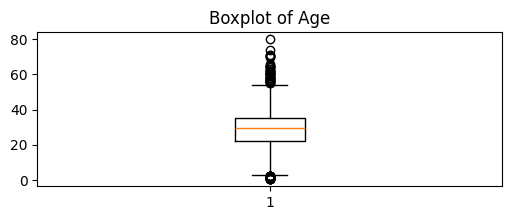

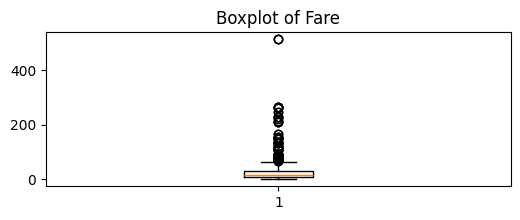

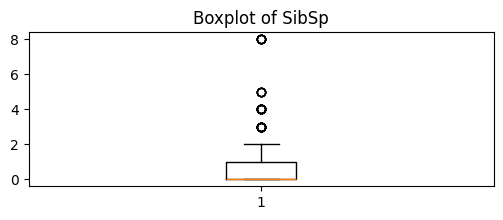

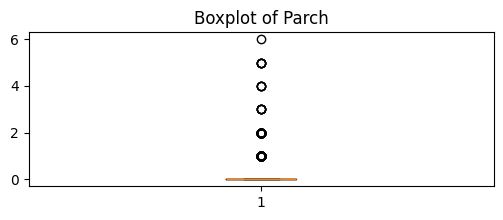

In [ ]:
#plotting boxplot for Numerical Columns
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
for col in numeric_cols:
  plt.figure(figsize=(6,2))
  plt.boxplot(df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()


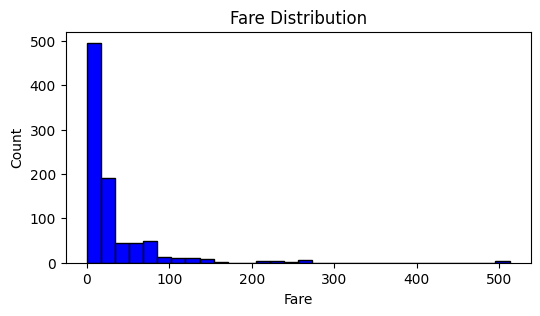

In [15]:
plt.figure(figsize=(6,3))
plt.hist(df['Fare'],bins=30,color='blue',edgecolor='black')
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

In [ ]:
#Identifying the Outliers
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
for col in numeric_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  print(f'Number of outliers in {col}: {len(outliers)}')

Number of outliers in Age: 66
Number of outliers in Fare: 116
Number of outliers in SibSp: 46
Number of outliers in Parch: 213


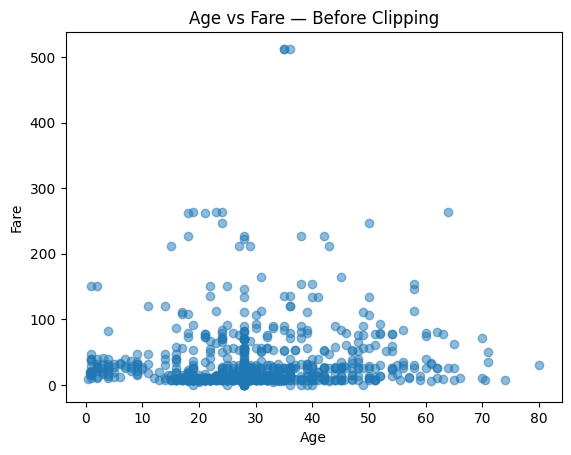

In [17]:
#Relationship between Age and fare before Clipping
plt.scatter(df['Age'], df['Fare'], alpha=0.5)
plt.title('Age vs Fare — Before Clipping')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()


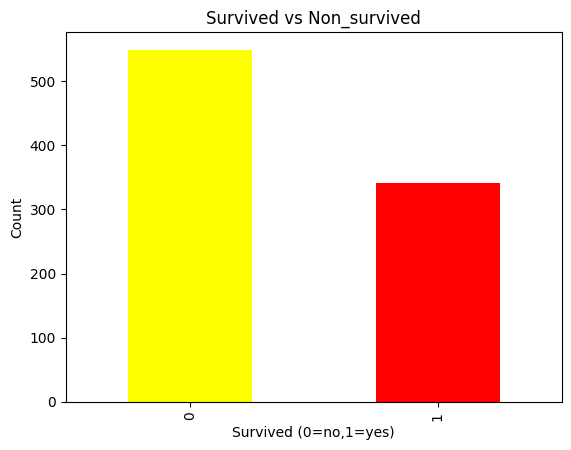

In [ ]:
#Plotting Barplot
df['Survived'].value_counts().plot(kind='bar',color=['yellow','Red'])
plt.title("Survived vs Non_survived")
plt.xlabel("Survived (0=no,1=yes)")
plt.ylabel("Count")
plt.show()

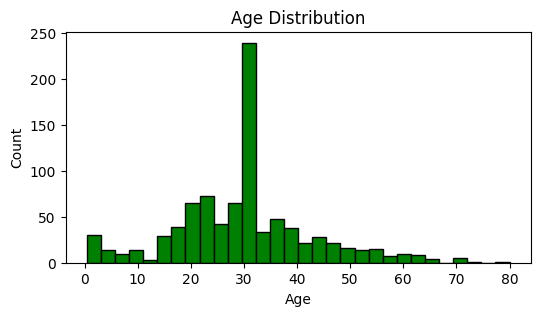

In [ ]:
#plotting Histogram
plt.figure(figsize=(6,3))
plt.hist(df['Age'],bins=30,color='green',edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
#clipping Outliers
Q1=df['Fare'].quantile(0.25)
Q3=df['Fare'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print(lower)
print(upper)
df['Fare']=df['Fare'].clip(lower,upper)

-26.724
65.6344


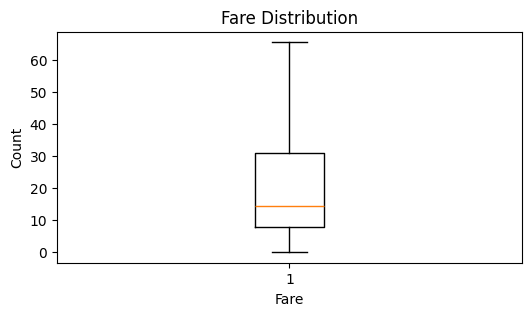

In [ ]:
#After Clipping Outliers
plt.figure(figsize=(6,3))
plt.boxplot(df['Fare'])
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

In [ ]:
#Normalizing Age and Fare Column
df['Age_norm']=(df['Age']-df['Age'].min())/(df['Age'].max()-df['Age'].min())
df['Fare_norm'] = (df['Fare'] - df['Fare'].min()) / (df['Fare'].max() - df['Fare'].min())

print(df[['Age', 'Age_norm', 'Fare', 'Fare_norm']].head())

    Age  Age_norm     Fare  Fare_norm
0  22.0  0.271174   7.2500   0.110460
1  38.0  0.472229  65.6344   1.000000
2  26.0  0.321438   7.9250   0.120745
3  35.0  0.434531  53.1000   0.809027
4  35.0  0.434531   8.0500   0.122649


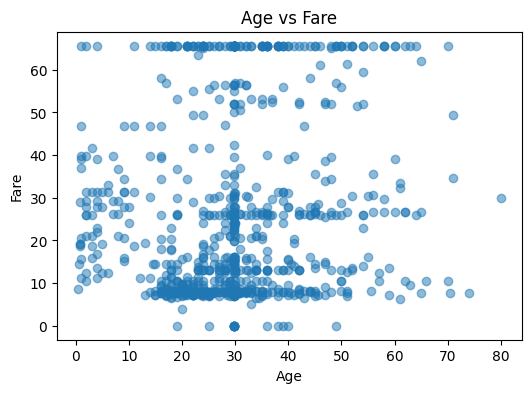

In [ ]:
#Relationship between - Fare and Age after Clipping
plt.figure(figsize=(6,4))
plt.scatter(df['Age'], df['Fare'], alpha=0.5)
plt.title('Age vs Fare after Clipping')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

In [ ]:
#Conclusion
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Data is clean and ready! ✅")

Shape: (891, 13)
Missing values: 0
Data is clean and ready! ✅


In [ ]:
# ================================
# CONCLUSIONS — Titanic EDA
# ================================

# 1. DATASET OVERVIEW
#    - 891 passengers, 12 columns
#    - Mix of numerical and categorical data

# 2. MISSING VALUES FOUND & FIXED
#    - Age:     177 missing → filled with median (28.0)
#    - Cabin:   687 missing → dropped (77% missing!)
#    - Embarked:  2 missing → filled with mode (S)

# 3. OUTLIERS FOUND & FIXED
#    - Fare had 116 outliers → clipped at 65.63
#    - Age had 11 outliers
#    - SibSp and Parch also had outliers

# 4. KEY FINDINGS FROM VISUALIZATION
#    - Only 38% of passengers survived
#    - Most passengers were aged 20-35
#    - Fare was heavily right skewed
#    - Age and Fare are weakly correlated

# 5. DATA IS NOW CLEAN & READY
#    - Missing values: 0
#    - Outliers: handled
#    - Numerical columns: normalized